# Forest Mask パラメータスイープ

`threshold` / closing kernel / opening kernel を変えながら結果を上下に比較する。

- 各行 = 1 つのパラメータ組み合わせ
- 列: Forest Mask / Closing / Opening
- CLI を介さず関数を直接呼ぶのでファイル出力は発生しない

## プリセット組み合わせ

| ラベル | threshold | closing | opening |
| --- | --- | --- | --- |
| 弱め | 5 | 3 | 0 (skip) |
| 現在基準 | 10 | 5 | 3 |
| 穴埋め強め | 10 | 7 | 3 |
| ノイズ除去強め | 10 | 5 | 5 |
| 森林判定を厳しめ | 20 | 5 | 3 |

`opening=0` は opening をスキップ (原 mask をそのまま表示) する扱い。

In [5]:
# プロジェクトルートで実行できるようにカレントを移動
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)

print("cwd:", Path.cwd())

cwd: /home/mqsol/works/forest-analyzer


In [6]:
# モジュールリロードを有効化（実装変更を即反映するため）
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# 入力読み込み + ExG (パラメータに依存しないので一度だけ計算)
from services.common.image import load_rgb
from services.forest_mask.exg import calc_exg

INPUT_PATH = Path("data/input/jpg/sample/sample_tree.jpg")

rgb = load_rgb(INPUT_PATH)
exg = calc_exg(rgb)

print("input:", INPUT_PATH)
print("rgb shape:", rgb.shape)
print("exg shape:", exg.shape, "dtype:", exg.dtype)

input: data/input/jpg/sample/sample_tree.jpg
rgb shape: (1534, 2048, 3)
exg shape: (1534, 2048) dtype: float32


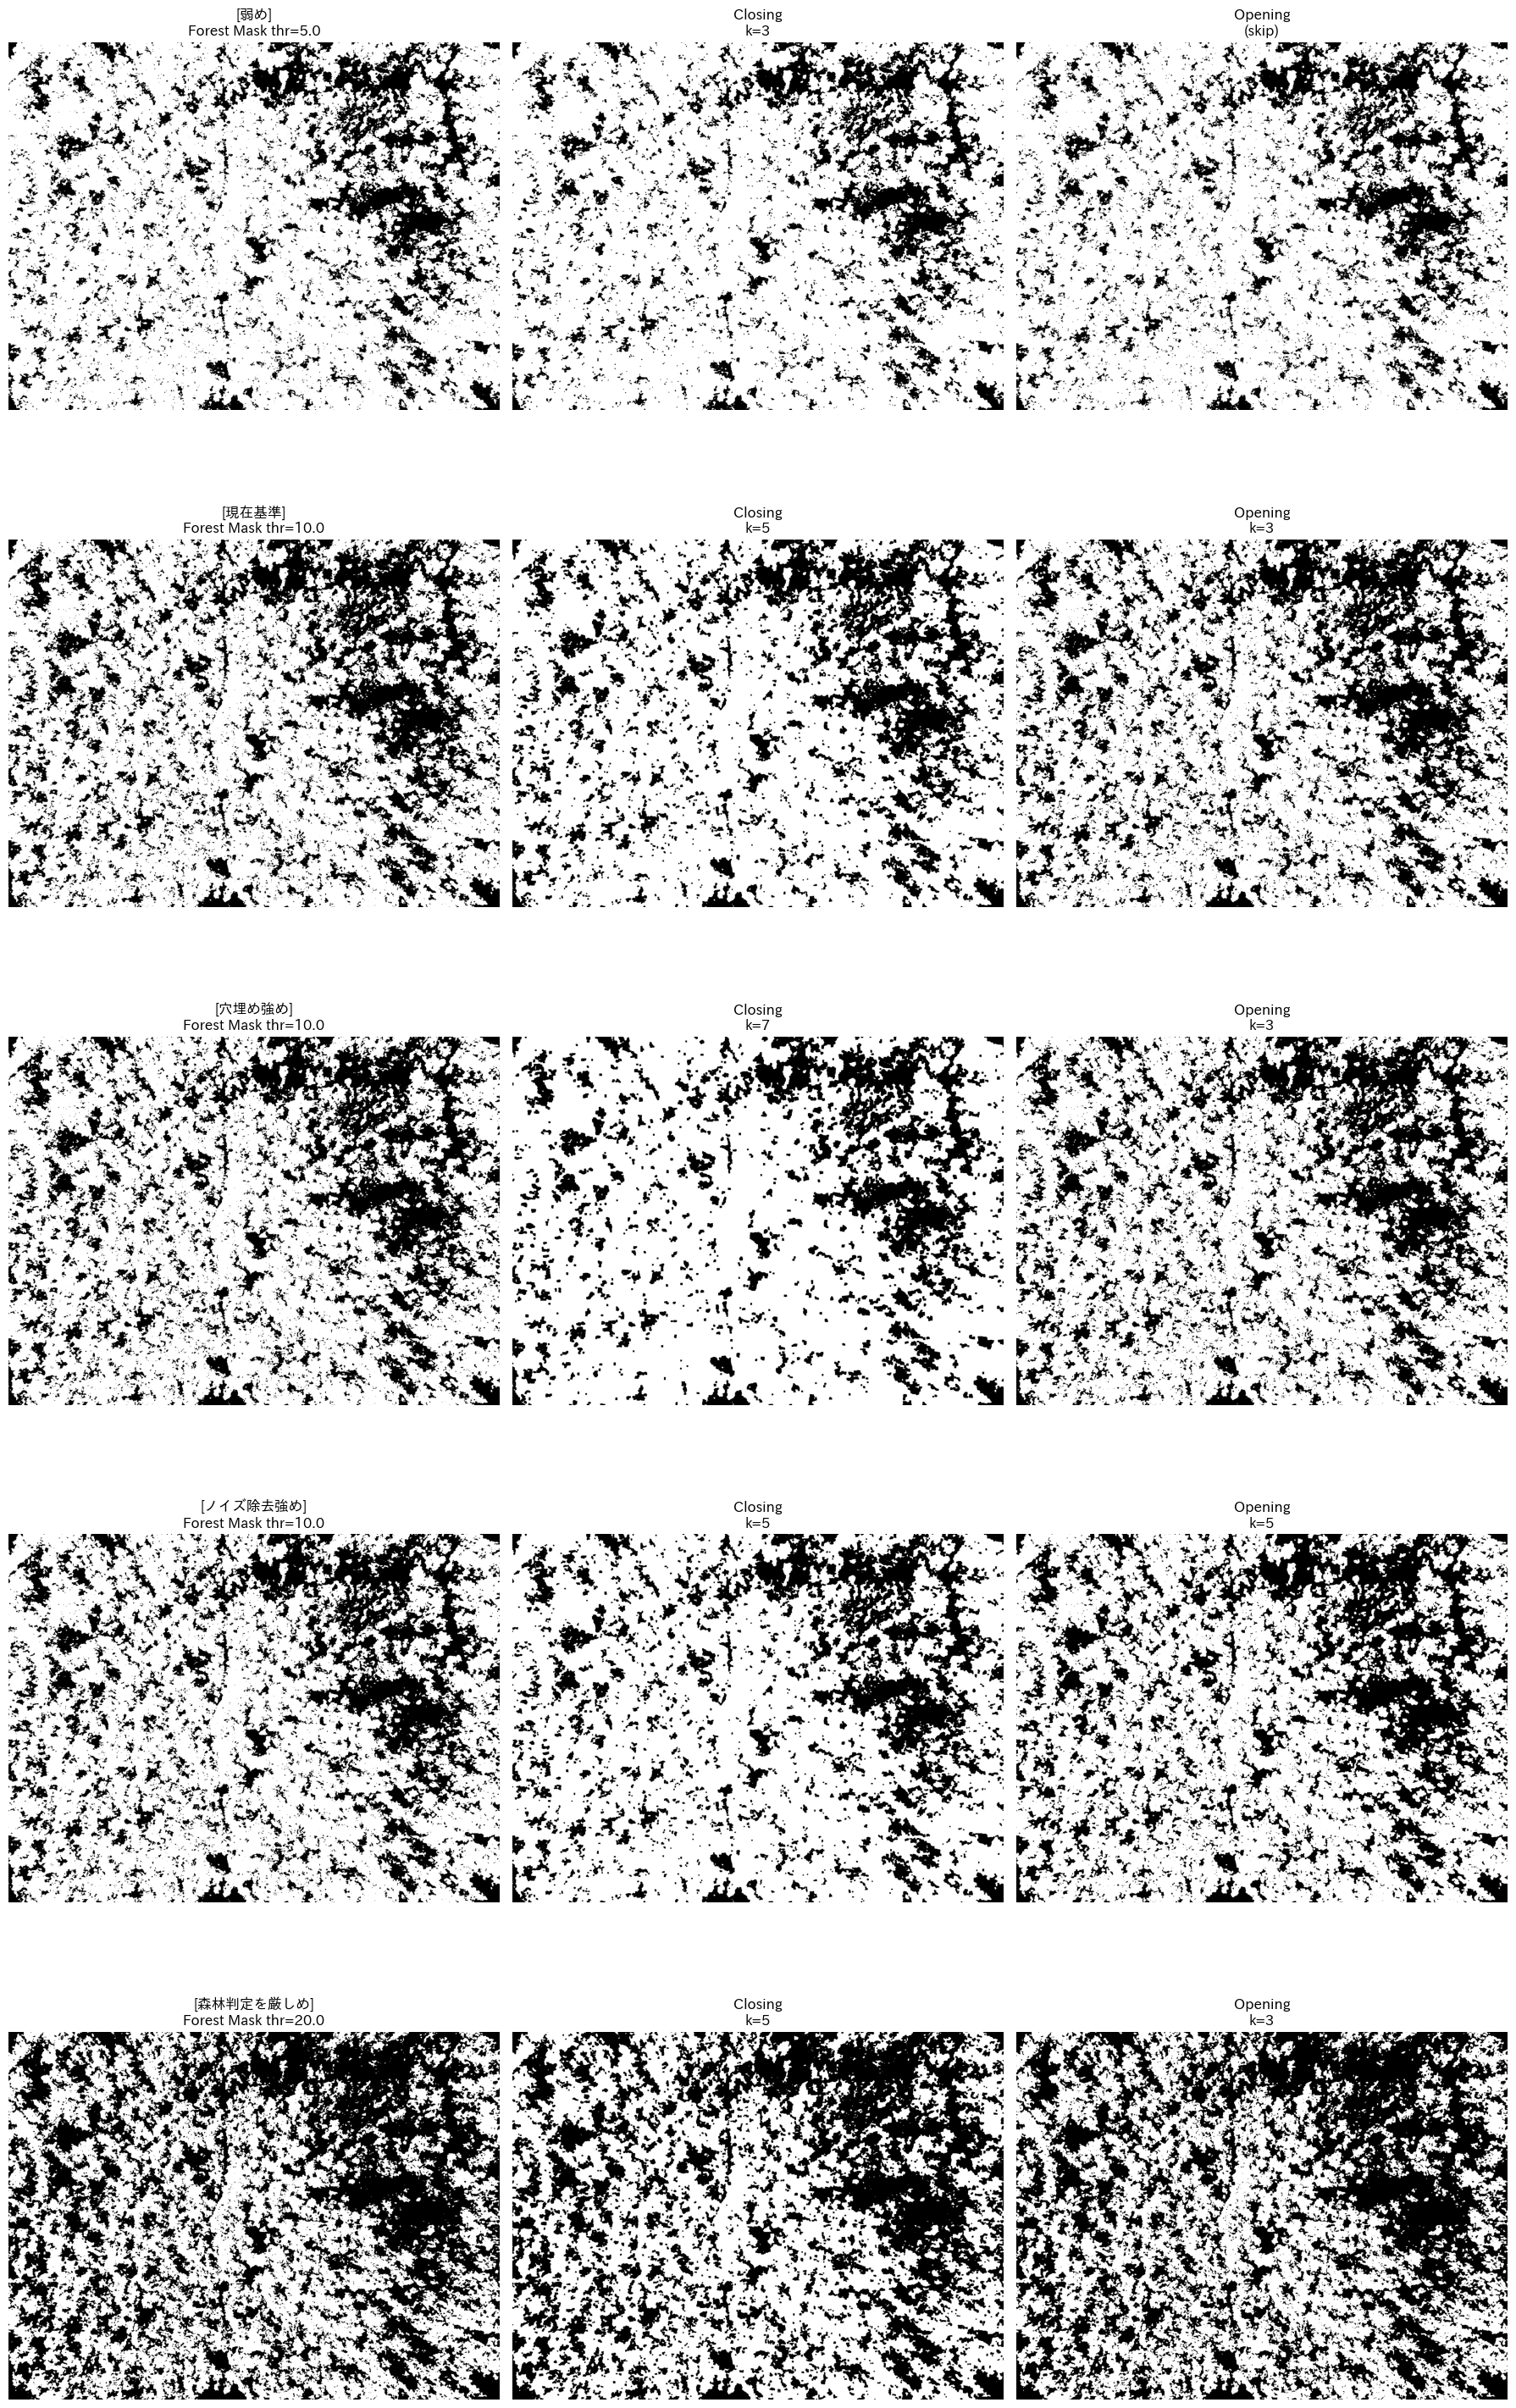

In [8]:
# パラメータ組み合わせを上下に並べて比較
# (label, threshold, closing_kernel, opening_kernel) を追加・削除して試行錯誤する
# kernel_size=0 のときは該当モルフォロジー処理をスキップする
import matplotlib.pyplot as plt
import japanize_matplotlib

from services.forest_mask.mask import calc_forest_mask
from services.forest_mask.morphology import apply_closing, apply_opening

PARAM_SETS = [
    # (label, threshold, closing_kernel, opening_kernel)
    ("弱め",            5.0,  3, 0),
    ("現在基準",         10.0, 5, 3),
    ("穴埋め強め",       10.0, 7, 3),
    ("ノイズ除去強め",   10.0, 5, 5),
    ("森林判定を厳しめ", 20.0, 5, 3),
]


def _maybe_close(mask, k):
    return apply_closing(mask, k) if k > 0 else mask


def _maybe_open(mask, k):
    return apply_opening(mask, k) if k > 0 else mask


n_rows = len(PARAM_SETS)
n_cols = 3  # Forest Mask / Closing / Opening

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
if n_rows == 1:
    axes = [axes]

for row_idx, (label, thr, k_close, k_open) in enumerate(PARAM_SETS):
    mask = calc_forest_mask(exg, thr)
    closed = _maybe_close(mask, k_close)
    opened = _maybe_open(mask, k_open)

    close_title = f"Closing\nk={k_close}" if k_close > 0 else "Closing\n(skip)"
    open_title = f"Opening\nk={k_open}" if k_open > 0 else "Opening\n(skip)"

    panels = [
        (f"[{label}]\nForest Mask thr={thr}", mask),
        (close_title, closed),
        (open_title, opened),
    ]
    for col_idx, (title, img) in enumerate(panels):
        ax = axes[row_idx][col_idx]
        ax.imshow(img, cmap="gray")
        ax.set_title(title)
        ax.axis("off")

plt.tight_layout()
plt.show()